In [5]:
# Importações necessárias para treino do modelo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [9]:
df = pd.read_csv('../data/features_30_sec.csv')

# Separar features e label
X = df.drop(['filename', 'length', 'label'], axis=1)
y = df['label']

# Codificar labels em números (blues=0, classical=1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features: {X.shape[1]}")
print(f"Exemplos: {X.shape[0]}")
print(f"\nMapeamento de gêneros:")
for i, genre in enumerate(le.classes_):
    print(f"  {i} → {genre}")

Features: 57
Exemplos: 1000

Mapeamento de gêneros:
  0 → blues
  1 → classical
  2 → country
  3 → disco
  4 → hiphop
  5 → jazz
  6 → metal
  7 → pop
  8 → reggae
  9 → rock


In [10]:
# Normalizar features (essencial para o SVM funcionar bem)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir em treino e teste de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2,      # 80% treino, 20% teste
    random_state=42,    # garante reprodutibilidade
    stratify=y_encoded  # mantém proporção dos gêneros
)

print(f"Treino: {X_train.shape[0]} músicas")
print(f"Teste:  {X_test.shape[0]} músicas")

Treino: 800 músicas
Teste:  200 músicas


In [11]:
# Treinar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_score = rf_model.score(X_test, y_test)

print(f"Random Forest — Acurácia: {rf_score:.2%}")

Random Forest — Acurácia: 68.50%


In [12]:
# Treinar XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_score = xgb_model.score(X_test, y_test)

print(f"XGBoost — Acurácia: {xgb_score:.2%}")

XGBoost — Acurácia: 73.50%


In [13]:
# Treinar SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_score = svm_model.score(X_test, y_test)

print(f"SVM — Acurácia: {svm_score:.2%}")

SVM — Acurácia: 73.00%


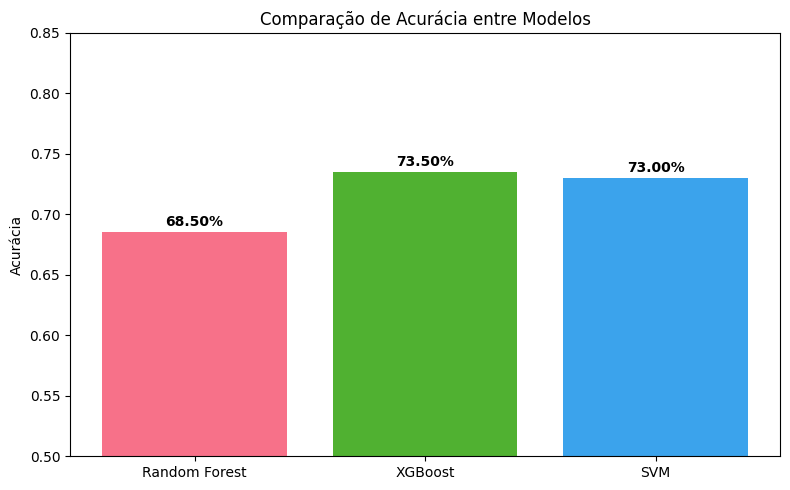

In [14]:
# Comparação visual dos modelos
modelos = ['Random Forest', 'XGBoost', 'SVM']
acuracias = [rf_score, xgb_score, svm_score]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, acuracias, color=sns.color_palette('husl', 3))
plt.title('Comparação de Acurácia entre Modelos')
plt.ylabel('Acurácia')
plt.ylim(0.5, 0.85)

# Adiciona o valor em cima de cada barra
for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

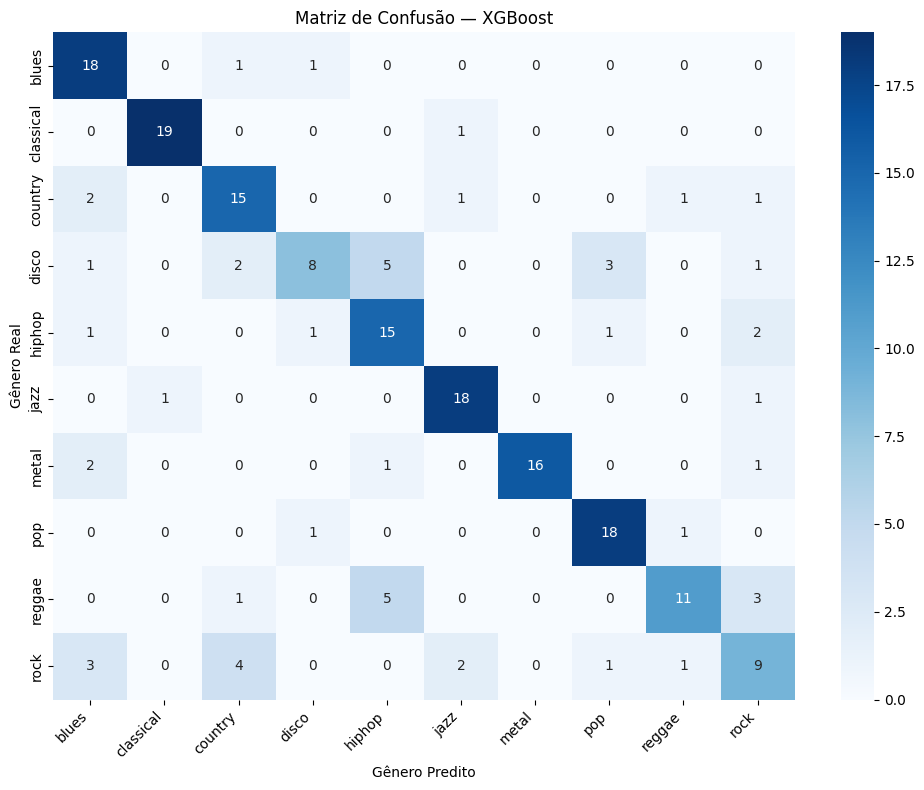

In [15]:
# Matriz de confusão do XGBoost (melhor modelo)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusão — XGBoost')
plt.ylabel('Gênero Real')
plt.xlabel('Gênero Predito')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Relatório detalhado por gênero
print("Classification Report — XGBoost")
print("=" * 50)
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

Classification Report — XGBoost
              precision    recall  f1-score   support

       blues       0.67      0.90      0.77        20
   classical       0.95      0.95      0.95        20
     country       0.65      0.75      0.70        20
       disco       0.73      0.40      0.52        20
      hiphop       0.58      0.75      0.65        20
        jazz       0.82      0.90      0.86        20
       metal       1.00      0.80      0.89        20
         pop       0.78      0.90      0.84        20
      reggae       0.79      0.55      0.65        20
        rock       0.50      0.45      0.47        20

    accuracy                           0.73       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.75      0.73      0.73       200



In [17]:
# Salvar o melhor modelo e o scaler
joblib.dump(xgb_model, '../model/xgb_music_classifier.pkl')
joblib.dump(scaler, '../model/scaler.pkl')
joblib.dump(le, '../model/label_encoder.pkl')

print("Modelo salvo com sucesso!")
print("Arquivos gerados:")
print("  model/xgb_music_classifier.pkl")
print("  model/scaler.pkl")
print("  model/label_encoder.pkl")

Modelo salvo com sucesso!
Arquivos gerados:
  model/xgb_music_classifier.pkl
  model/scaler.pkl
  model/label_encoder.pkl
